# **Twitter Sentiment Analysis with Supervised Learning**

1. Initial data transformation
2. Simple visualization
3. Logistic Regression model

In [14]:
# 필요한 라이브러리를 import하세요.
import pandas as pd
import re
import nltk
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nltk.download('punkt_tab')
nltk.download('punkt')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

## **1. 데이터 불러오기**

* twitter_training 데이터는 train으로, twitter_validation 데이터는 val로 불러오세요.
  * `header=None` 옵션으로 불러오세요.

In [3]:
train = pd.read_csv('/content/twitter_training.csv', header=None)
val = pd.read_csv('/content/twitter_validation.csv', header=None)

In [4]:
train.head()

,0,1,2,3
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [5]:
val.head()

,0,1,2,3
0,3364,Facebook,Irrelevant,I mentioned on Facebook that I was struggling ...
1,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
2,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
3,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
4,4433,Google,Neutral,Now the President is slapping Americans in the...


## **2. 전처리**
* train은 훈련 데이터셋, val은 검증 데이터셋입니다.
* 각 열의 이름을 id, information, type, text로 설정해주세요.

In [6]:
# 해당 셀을 실행해주세요.
train.columns=['id','information','type','text']
val.columns=['id','information','type','text']

In [7]:
train.head()

,id,information,type,text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [8]:
val.head()

,id,information,type,text
0,3364,Facebook,Irrelevant,I mentioned on Facebook that I was struggling ...
1,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
2,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
3,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
4,4433,Google,Neutral,Now the President is slapping Americans in the...


In [9]:
# train 데이터와 val 데이터의 text 열을 소문자로 바꾸고, NaN 값은 공백으로 대체하는 코드를 작성하세요.
train['text'] = train['text'].str.lower().fillna('')
val['text'] = val['text'].str.lower().fillna('')

### Removing non-English characters

In [10]:
# train 데이터와 val 데이터의 text 열 중 영어 문자열이 아닌 문자는 모두 공백으로 변환하는 코드를 작성하세요.
train['text'] = train['text'].apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', x))
val['text'] = val['text'].apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', x))

## **3. 시각화**
* information(각 브랜드) 별 type의 개수를 보여주는 막대 그래프를 그리세요.
  * x축에는 Brand가, y축에는 Number of tweets가 오도록하고, x축명, y축명을 각각 'Brand', 'Number of tweets'로 설정해주세요.
  * type별로 막대 색이 다르게 나올 수 있도록 설정해주세요.
  * 제안 : groupby를 사용하여 데이터프레임을 만든 후 시각화하셔도 됩니다.

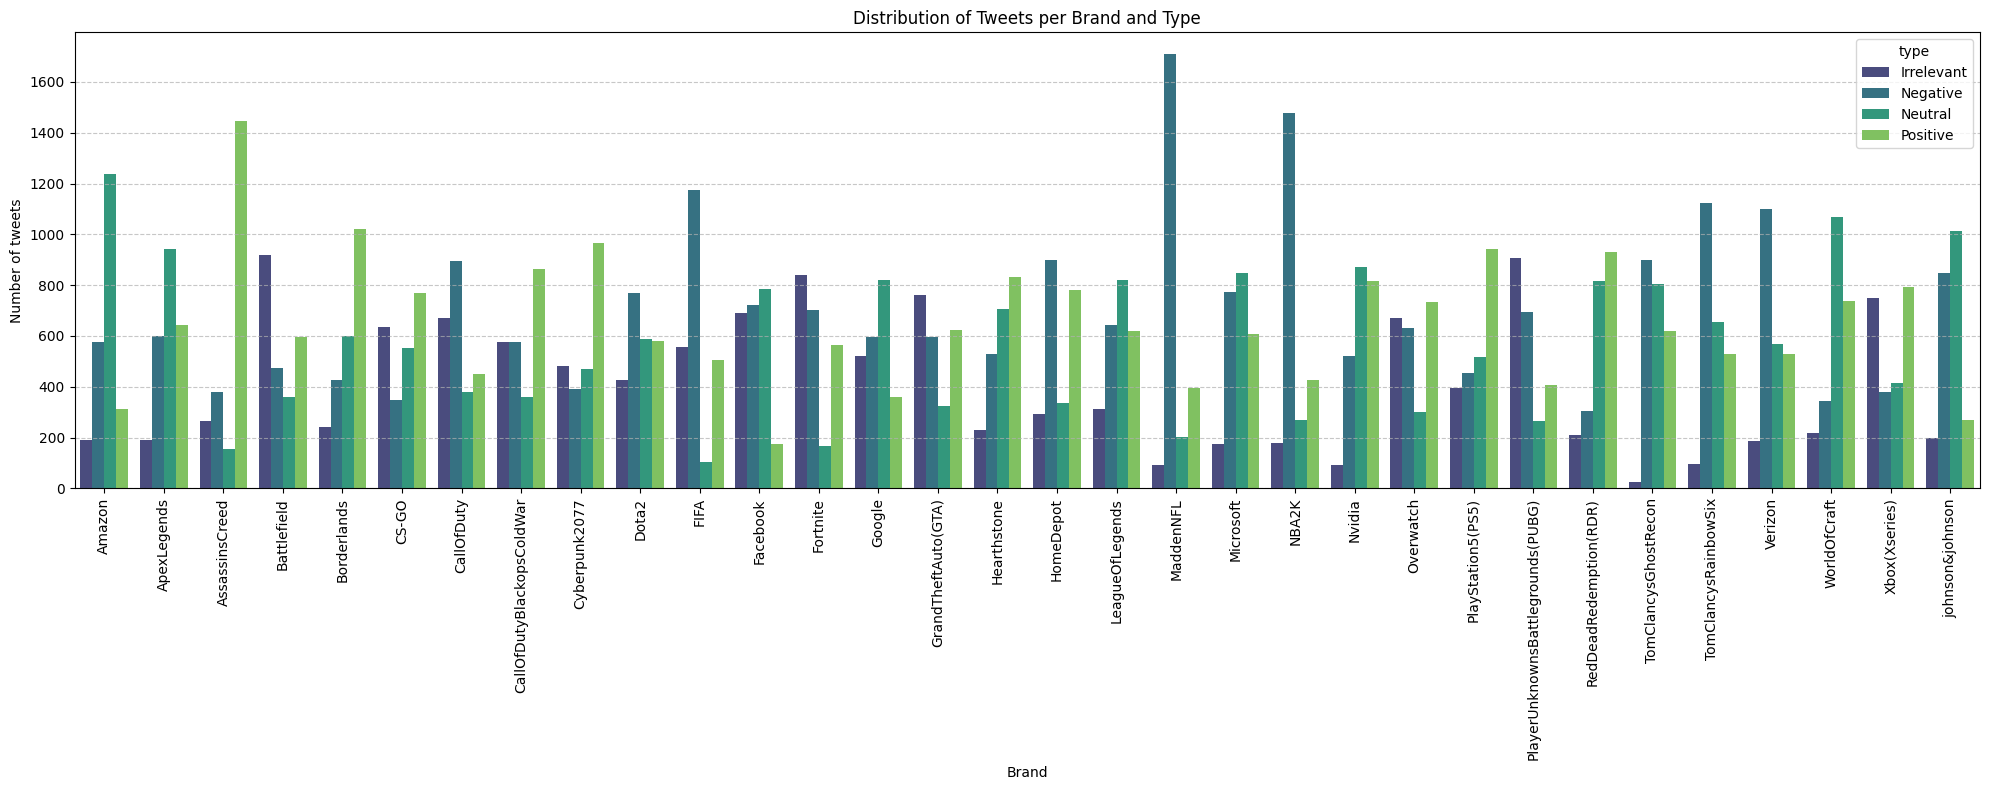

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by 'information' and 'type' and count occurrences
brand_type_counts = train.groupby(['information', 'type']).size().reset_index(name='Number of tweets')

# Create the bar plot
plt.figure(figsize=(20, 8))
sns.barplot(data=brand_type_counts, x='information', y='Number of tweets', hue='type', palette='viridis')
plt.title('Distribution of Tweets per Brand and Type')
plt.xlabel('Brand')
plt.ylabel('Number of tweets')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## **4. 피처 벡터화 변환과 머신러닝 모델 학습/예측/평가**
* Count 벡터화를 적용해 예측 성능을 측정해보세요.
    * Classifier는 LogisticRegression을 이용합니다.
    * 예측 성능 평가는 다중 분류임을 고려해 정확도, F1 score, 혼동행렬을 모두 측정합니다. Classification Report를 출력해도 무방합니다.
    * `tokenizer=word_tokenize, stop_words='english', ngram_range=(1, 1)`으로 지정해주세요.
    * 파이프라인 객체를 이용하는 것은 선택 사항입니다.

In [15]:
# Count Vectorization with Logistic Regression

# Define the pipeline
pipeline_count = Pipeline([
    ('vect', CountVectorizer(tokenizer=word_tokenize, stop_words='english', ngram_range=(1, 1))),
    ('clf', LogisticRegression(random_state=42, solver='liblinear'))
])

# Train the model
pipeline_count.fit(train['text'], train['type'])

# Predict on the validation set
y_pred_count = pipeline_count.predict(val['text'])

# Evaluate the model
accuracy_count = accuracy_score(val['type'], y_pred_count)
conf_matrix_count = confusion_matrix(val['type'], y_pred_count)
class_report_count = classification_report(val['type'], y_pred_count)

print(f"Validation Accuracy: {accuracy_count:.2f}%")
print("Confusion Matrix:\n", conf_matrix_count)
print("Classification Report:\n", class_report_count)

/usr/local/lib/python3.13/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Validation Accuracy: 0.94%
Confusion Matrix:
 [[155   4   3  10]
 [  1 254   4   7]
 [  3  10 264   8]
 [  5   8   1 263]]
Classification Report:
               precision    recall  f1-score   support

  Irrelevant       0.95      0.90      0.92       172
    Negative       0.92      0.95      0.94       266
     Neutral       0.97      0.93      0.95       285
    Positive       0.91      0.95      0.93       277

    accuracy                           0.94      1000
   macro avg       0.94      0.93      0.93      1000
weighted avg       0.94      0.94      0.94      1000



* TF-IDF 벡터화를 적용해 예측 성능을 측정해 보세요.
    * Classifier는 LogisticRegression을 이용합니다.
    * 예측 성능 평가는 다중 분류임을 고려해 정확도, F1 score, 혼동행렬을 모두 측정합니다. Classification Report를 출력해도 무방합니다.
    * `stop_words='english', ngram_range=(1, 2)`으로 지정해주세요.
    * 파이프라인 객체를 이용하는 것은 선택 사항입니다.


In [16]:
# TF-IDF Vectorization with Optimization

# Define the pipeline
pipeline_tfidf_optimized = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', ngram_range=(1, 3))), # increased ngram_range
    ('clf', LogisticRegression(random_state=42, solver='liblinear', C=1.0, max_iter=200)) # Increased max_iter
])

# Train the model
pipeline_tfidf_optimized.fit(train['text'], train['type'])

# Predict on the validation set
y_pred_tfidf_optimized = pipeline_tfidf_optimized.predict(val['text'])

# Evaluate the model
accuracy_optimized = accuracy_score(val['type'], y_pred_tfidf_optimized)
conf_matrix_optimized = confusion_matrix(val['type'], y_pred_tfidf_optimized)
class_report_optimized = classification_report(val['type'], y_pred_tfidf_optimized)

print(f"Optimized Validation Accuracy: {accuracy_optimized:.2f}%")
print("Optimized Confusion Matrix:\n", conf_matrix_optimized)
print("Optimized Classification Report:\n", class_report_optimized)

Optimized Validation Accuracy: 0.97%
Optimized Confusion Matrix:
 [[165   3   0   4]
 [  1 260   3   2]
 [  0   2 277   6]
 [  0   6   2 269]]
Optimized Classification Report:
               precision    recall  f1-score   support

  Irrelevant       0.99      0.96      0.98       172
    Negative       0.96      0.98      0.97       266
     Neutral       0.98      0.97      0.98       285
    Positive       0.96      0.97      0.96       277

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000



## **5. 최적화** (보너스 문제)

파라미터를 조절하여 가장 높은 정확도를 가지는 모델을 만들고, 조원들과 공유해보세요.

* 제안
    * CountVectorizer, TfidfVectorizer에서는 `stop_words, ngram_range` 조절
    * LogisticRegression에서는 `C, max_iter` 조절

In [17]:
from sklearn.model_selection import GridSearchCV

# Define the pipeline for optimization
pipeline_tfidf_logreg = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LogisticRegression(random_state=42, solver='liblinear'))
])

# Define the parameter grid to search
param_grid = {
    'tfidf__ngram_range': [(1, 1), (1, 2), (1, 3)],  # Try different n-gram ranges
    'clf__C': [0.1, 1.0, 10.0],  # Regularization parameter for Logistic Regression
    'clf__max_iter': [100, 200, 300] # Maximum number of iterations
}

# Initialize GridSearchCV
grid_search = GridSearchCV(pipeline_tfidf_logreg, param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the training data
grid_search.fit(train['text'], train['type'])

# Print the best parameters and the best score
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation accuracy: {:.2f}%".format(grid_search.best_score_ * 100))

# Evaluate the best model on the validation set
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(val['text'])

accuracy_best = accuracy_score(val['type'], y_pred_best)
conf_matrix_best = confusion_matrix(val['type'], y_pred_best)
class_report_best = classification_report(val['type'], y_pred_best)

print(f"\nOptimized Model Validation Accuracy: {accuracy_best:.2f}%")
print("Optimized Model Confusion Matrix:\n", conf_matrix_best)
print("Optimized Model Classification Report:\n", class_report_best)

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best parameters found:  {'clf__C': 1.0, 'clf__max_iter': 100, 'tfidf__ngram_range': (1, 3)}
Best cross-validation accuracy: 47.93%

Optimized Model Validation Accuracy: 0.97%
Optimized Model Confusion Matrix:
 [[166   3   0   3]
 [  0 262   2   2]
 [  0   2 279   4]
 [  1   6   2 268]]
Optimized Model Classification Report:
               precision    recall  f1-score   support

  Irrelevant       0.99      0.97      0.98       172
    Negative       0.96      0.98      0.97       266
     Neutral       0.99      0.98      0.98       285
    Positive       0.97      0.97      0.97       277

    accuracy                           0.97      1000
   macro avg       0.98      0.97      0.98      1000
weighted avg       0.98      0.97      0.98      1000

